## CNN sad or happy
This convolutional neural network built with Keras is trained to detect if the person in the photo is sad or happy. \
Authour: Rebecka Antonsson

### Model
- Two convolutional layers
- LeakyReLU activation
- Flatten + fully connected output layer
- Softmax classification
- Adam optimizer
- Categorical cross-entropy loss

### Data preprocessing
- Face cropping
- Grayscale conversion
- Resize
- Normalization

### Evaluation
- Train/test split
- Test accuracy
- Example predictions
- Visualization of learned convolutional filters

### Results
Test accuracy 85.7%

### Technologies
Python, TensorFlow/Keras, OpenCV, NumPy, Matplotlib

In [ ]:
# Load libraries
import zipfile
import sys,os
import numpy as np
import cv2
import keras

from keras.models import Sequential,Model
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import LeakyReLU
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical


import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
# Load the images
path_to_face_zip = r"C:/Users/rebbe/Master/BERN02/Neural_networks/faces.zip"

# unzip the loaded folder
with zipfile.ZipFile(path_to_face_zip, "r") as zip_ref:
    zip_ref.extractall("faces")

In [10]:
from matplotlib import image
path_to_files = "faces"
data=[]
list_of_files=os.listdir(os.sep.join([path_to_files,'faces']))
for filename in sorted(list_of_files):
    img = image.imread(os.sep.join([path_to_files,'faces',filename]))
    print(f"Shape of {filename}: {img.shape}")
    # Dynamically calculate slicing dimensions to extract the central part
    height, width, _ = img.shape
    start_row = max(0, height // 2 - 200)
    end_row = min(height, height // 2 + 200)
    start_col = max(0, width // 2 - 150)
    end_col = min(width, width // 2 + 150)
    cropped_img = img[start_row:end_row, start_col:end_col, :]

    data.append(cropped_img)

axis_list=[]
fig,ax=plt.subplots(1,len(data),figsize=(18,8))
for i,img in enumerate(data):
    ax[i].imshow(img,cmap='gray')

# 32 images, 1 = happy, 0 = sad
happy=np.array([1,1,1,1,1,1,1,1,1,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1])

# Ensure the number of happy labels matches the number of images
if len(happy) != len(data):
    raise ValueError("Number of happy labels does not match the number of images")


data=[cv2.resize(img.mean(axis=2)/255,dsize=(36,36)) for img in data]
data=np.array(data)
label=np.vstack((happy,np.negative(happy)+1)).T

Shape of WIN_20251015_09_27_38_Pro.jpg: (541, 379, 3)
Shape of WIN_20251015_09_27_40_Pro.jpg: (489, 341, 3)
Shape of WIN_20251015_09_27_41_Pro (2).jpg: (469, 338, 3)
Shape of WIN_20251015_09_27_41_Pro.jpg: (496, 346, 3)
Shape of WIN_20251015_09_27_42_Pro.jpg: (465, 353, 3)
Shape of WIN_20251015_09_27_43_Pro (2).jpg: (477, 361, 3)
Shape of WIN_20251015_09_27_43_Pro.jpg: (457, 357, 3)
Shape of WIN_20251015_09_27_45_Pro.jpg: (383, 287, 3)
Shape of WIN_20251015_09_27_47_Pro.jpg: (467, 363, 3)
Shape of WIN_20251015_09_27_49_Pro.jpg: (458, 358, 3)
Shape of WIN_20251015_09_27_50_Pro.jpg: (482, 394, 3)
Shape of WIN_20251015_09_27_54_Pro.jpg: (585, 468, 3)
Shape of WIN_20251015_09_27_56_Pro.jpg: (637, 455, 3)
Shape of WIN_20251015_09_27_57_Pro.jpg: (629, 455, 3)
Shape of WIN_20251015_09_28_00_Pro.jpg: (545, 371, 3)
Shape of WIN_20251015_09_28_01_Pro.jpg: (528, 372, 3)
Shape of WIN_20251015_09_28_02_Pro (2).jpg: (550, 370, 3)
Shape of WIN_20251015_09_28_02_Pro.jpg: (528, 391, 3)
Shape of WIN_202

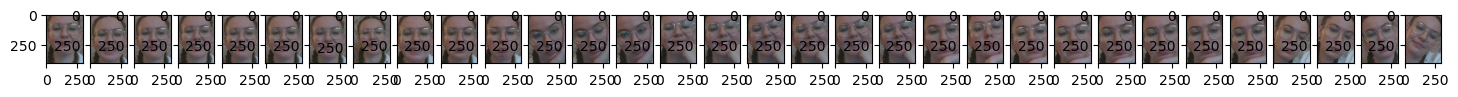

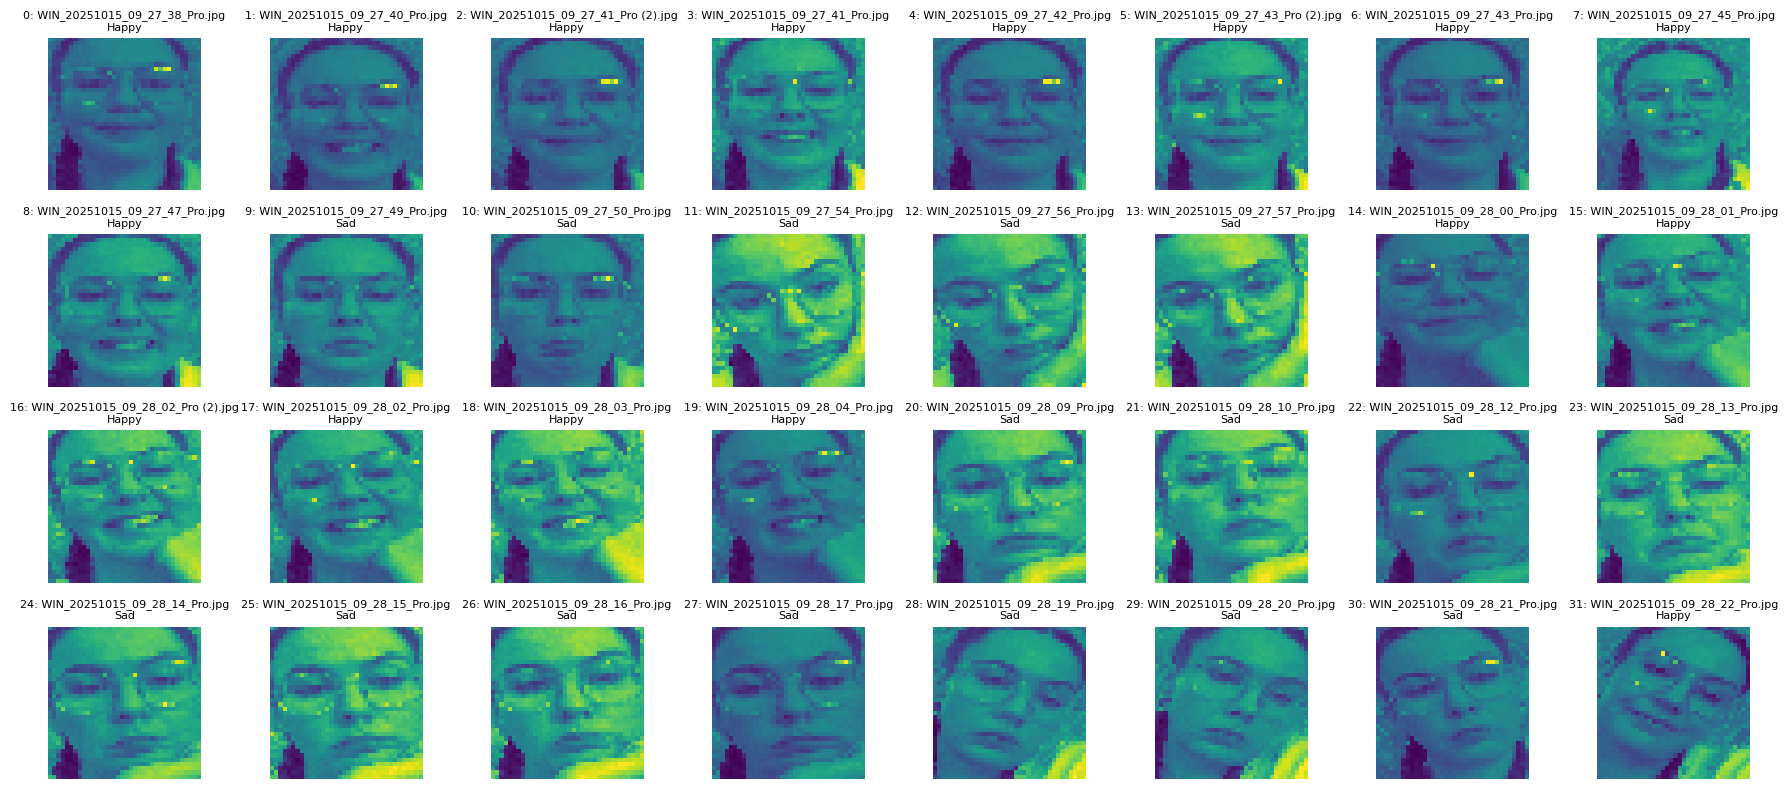

In [11]:
# Print the images with labels to make sure they are labeled correctly
fig, axes = plt.subplots(4, 8, figsize=(18, 8))
axes = axes.ravel()

for i, (img, fname, lbl) in enumerate(zip(data, list_of_files, happy)):
    label_text = "Happy" if lbl == 1 else "Sad"
    axes[i].imshow(img)
    axes[i].set_title(f"{i}: {fname}\n{label_text}", fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [12]:
# Test and training split
data_train, data_test, label_train, label_test = train_test_split(
    data,
    label,
    test_size=0.2,
    random_state=42,
    stratify=label
)

In [13]:
# Set modelling parameter

epochs = 50     # Total throughput
num_classes = 2 # Categories

face_model = Sequential()
face_model.add(Conv2D(36, kernel_size=(3,3),activation='linear',input_shape=(36,36,1),padding='same'))
face_model.add(LeakyReLU(alpha=0.1))
face_model.add(Conv2D(72, (1, 1), activation='linear',padding='same'))
face_model.add(LeakyReLU(alpha=0.1))
face_model.add(Flatten())
face_model.add(Dense(num_classes, activation='softmax'))
face_model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adam(),metrics=['accuracy'])
face_model.summary()
face_train = face_model.fit(data_train, label_train, epochs=epochs,verbose=1)

c:\Users\rebbe\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


c:\Users\rebbe\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 36, 36, 36)     │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 36, 36, 36)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 36, 36, 72)     │         2,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 36, 36, 72)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 93312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │       186,626 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,650 (740.82 KB)

 Trainable params: 189,650 (740.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6400 - loss: 0.6908
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5200 - loss: 0.9148
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4800 - loss: 0.6290
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4800 - loss: 0.7614
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4800 - loss: 0.6523
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9200 - loss: 0.5554
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.5200 - loss: 0.5785
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5200 - loss: 0.5789
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6400 - loss: 0.5215
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9200 - loss: 0.4623
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9600 - loss: 0.4297
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9200 - loss: 0.4157
Ep

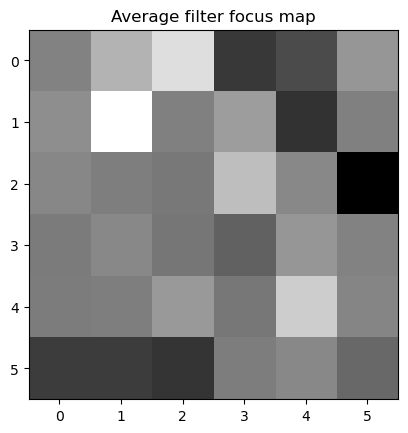

In [17]:
weights=face_model.layers[0].get_weights()[0]
weights=weights.mean(axis=0).mean(axis=0).mean(axis=0)
reshaped_weights = weights.reshape(6,6)
reshaped_weights-=reshaped_weights.min()
reshaped_weights/=reshaped_weights.max()
plt.imshow(reshaped_weights, cmap='gray')
plt.title("Average filter focus map")
plt.show()



The plot of the average filter focus map shows bright colors where the model has learnt to pay the most attention. These weight seems to put a most attention around the top right corner (1,1) and (0,2), and some attention in blocks (2,3) and (4,4).

In [ ]:
# Accuracy and loss of the model
test_loss, test_accuracy = face_model.evaluate(data_test, label_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8571 - loss: 0.1582


In [ ]:
# Make predictions of the test data
predictions = face_model.predict(data_test)
predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


array([[4.5818757e-04, 9.9954188e-01],
       [3.4636965e-03, 9.9653625e-01],
       [2.4464837e-04, 9.9975532e-01],
       [6.7403746e-01, 3.2596251e-01],
       [4.9726540e-01, 5.0273460e-01],
       [2.6241781e-03, 9.9737585e-01],
       [9.9281764e-01, 7.1823401e-03]], dtype=float32)

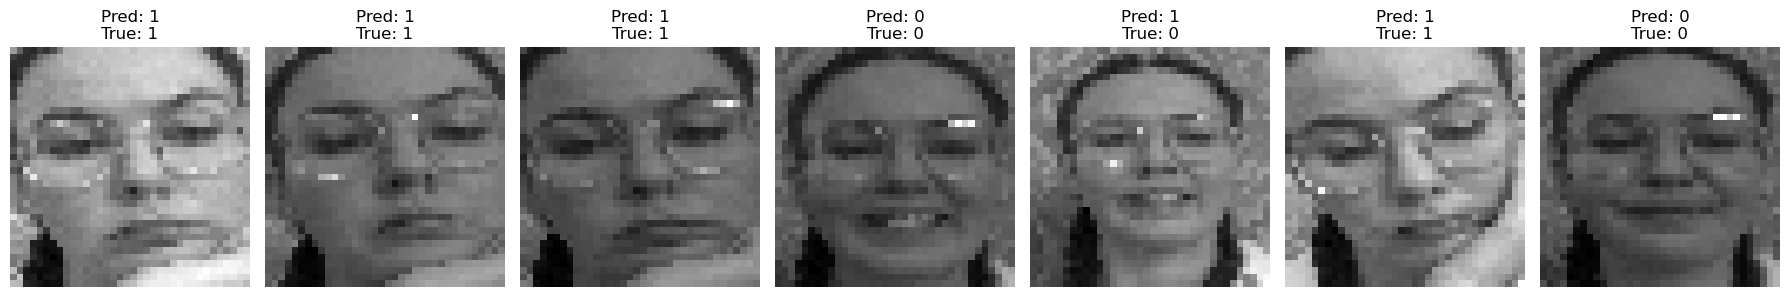

In [ ]:
# Plot the predicted pictures with their predicted and true labels
fig, ax = plt.subplots(1, len(data_test), figsize=(18, 5))

for i, img in enumerate(data_test):
    predicted_class = np.argmax(predictions[i])
    true_class = np.argmax(label_test[i])

    ax[i].imshow(img, cmap='gray')
    ax[i].set_title(
        f"Pred: {predicted_class}\nTrue: {true_class}"
    )
    ax[i].axis('off')

plt.tight_layout()
plt.show()